# Regional influence: leave-one-region-out sensitivity

Spatial colocalization returns a single number per receptor or cell type — the correlation across all brain regions. But the spatial patterns we compare between brain maps are not homogenously similar or different: some regions may drive the colocalization strongly while others contribute little or suppress it.

**Regional influence** asks: *how much does the reported colocalization change when each region is excluded?*

Formally, for each region $i$:
$$\text{influence}_i = \rho_{\text{full}} - \rho_{\text{LOO}(-i)}$$

A large positive value means the region inflates the colocalization; a large negative value means it suppresses it. Regions near zero are not influential.

This is **not** Cook's distance or DFFITS, which flag statistical outliers. Regional influence asks a different question: *which brain regions drive the reported scientific effect?*

NiSpace implements `regional_influence()` with two engines:
- **Analytic** (`engine="analytic"`): closed-form case-deletion identities (Sherman-Morrison downdate for MLR, running-sum downdate for Pearson/Spearman). Numerically identical to a real refit, but O(n) total instead of O(n²). Works for `pearson`, `spearman`, `partialpearson`, `partialspearman`, `mlr`.
- **Bruteforce** (`engine="bruteforce"`): reruns `colocalize()` with each region deleted. Works for any method except `lasso`, `ridge`, `elasticnet`.
- **`engine="auto"`** (default): picks analytic when available, bruteforce otherwise.

> **Prerequisite**: this notebook loads pre-computed NiSpace objects saved in
> [intro02](intro02_nispace_intro.ipynb) and [intro10](intro10_xsea.ipynb).
> Run those two notebooks first to generate `intro02_nsp.pkl.blosc` and `intro10_nsp.pkl.blosc`.

In [2]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from nispace.api import NiSpace
from nispace.plotting import brainplot

## Load pre-computed NiSpace objects

We load two NiSpace objects with existing colocalization and permutation results:
- **nsp02**: pain map vs. PET receptor maps (Spearman, Yan200) — from [intro02](intro02_nispace_intro.ipynb)
- **nsp10**: pain map vs. mRNA cell type markers, XSEA (Spearman, Yan100+TianS1) — from [intro10](intro10_xsea.ipynb)

In [3]:
nsp02 = NiSpace.from_pickle("intro02_nsp.pkl.blosc")
print("nsp02 — pain × PET (Yan200):")
print(nsp02.get_colocalizations().loc["Pain"].sort_values(ascending=False).head(5))

print()
nsp10 = NiSpace.from_pickle("intro10_nsp.pkl.blosc")
print("nsp10 — pain × mRNA XSEA (Yan100+TianS1):")
print(nsp10.get_colocalizations().loc["Pain"].sort_values(ascending=False).head(5))

nsp02 — pain × PET (Yan200):
INFO | 15/07/26 09:48:15 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 


set                          map                                                   
Noradrenaline/Acetylcholine  target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017    0.422783
Opioids/Endocannabinoids     target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018      0.335397
Noradrenaline/Acetylcholine  target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017            0.288889
Histamine                    target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017     0.273213
Glutamate                    target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019      0.180214
Name: Pain, dtype: float32

nsp10 — pain × mRNA XSEA (Yan100+TianS1):
INFO | 15/07/26 09:48:15 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 


Microglia          0.237071
Astrocyte          0.193244
OPC                0.168680
Endothelial        0.167029
Oligodendrocyte    0.153288
Name: Pain, dtype: float32


## Example 1: standard colocalization (PET receptors)

For `spearman` colocalization, `regional_influence()` produces one influence profile per X-map (receptor). We ask:  
*Which brain regions drive the colocalization between the pain map and the top receptor (VAChT — the vesicular acetylcholine transporter)?*

For a simple brain-with-brain correlation, this question can also be approached by just looking at the scatter plot: 

INFO | 15/07/26 09:48:15 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 


Top receptor: ('Noradrenaline/Acetylcholine', 'target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017')
INFO | 15/07/26 09:48:15 | nispace.api: Returning X dataframe: 
| X_REDUCTION | 
| False       | 


INFO | 15/07/26 09:48:15 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| False       | 


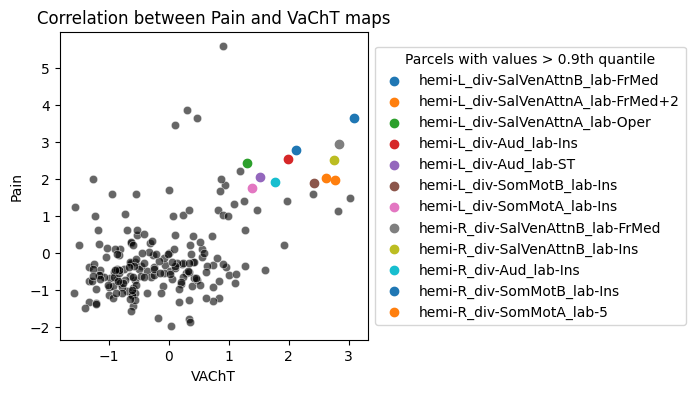

In [4]:
# Identify the top receptor by |rho|
top_pet = nsp02.get_colocalizations().loc["Pain"].abs().idxmax()
print(f"Top receptor: {top_pet}")

# get parcellated data to show the scatter plot
x = nsp02.get_x().loc[top_pet]
y = nsp02.get_y().squeeze()

# plot scatter
fig, ax = plt.subplots(1, figsize=(4,4))
sn.scatterplot(x=x, y=y, c="k", alpha=0.6)
ax.set_box_aspect(1)
ax.set_title("Correlation between Pain and VaChT maps")
ax.set_xlabel("VAChT")
for xx, yy, parcel in zip(x, y, x.index):
    if xx > np.quantile(x, 0.9) and yy > np.quantile(y, 0.9):
        ax.scatter(xx, yy, label=parcel)
ax.legend(loc="center left", bbox_to_anchor=(1,0.5), title=f"Parcels with values > 0.9th quantile")

Now compute the regional influence and visualize it in a similar scatter plot

In [5]:
# Compute regional influence (uses analytic engine automatically for spearman)
nsp02.regional_influence()

# Retrieve results: dict keyed by X-map label (receptor), each value (n_Y × n_parcels)
ri02 = nsp02.get_regional_influence()
print(f"Type: {type(ri02)}")
print(f"Keys (first 3): {list(ri02.keys())[:3]}")
print(f"Shape per receptor: {next(iter(ri02.values())).shape}  (n_Y × n_parcels)")

INFO | 15/07/26 09:48:16 | nispace.api: *** NiSpace.regional_influence() - Estimating regional influence. ***


Regional influence (spearman, analytic, 4 proc): 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.01it/s]

Type: <class 'dict'>
Keys (first 3): [('General', 'target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023'), ('General', 'target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith2023'), ('General', 'target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016')]
Shape per receptor: (1, 200)  (n_Y × n_parcels)


In [6]:
# Show top-5 and bottom-5 regions by influence
ri_series = ri02[top_pet].squeeze()  # (n_parcels,) Series
print("Regions most inflating the VAChT colocalization (top 5):")
print(ri_series.sort_values(ascending=False).head(5).to_string())
print("\nRegions most suppressing it (bottom 5):")
print(ri_series.sort_values().head(5).to_string())

Regions most inflating the VAChT colocalization (top 5):
hemi-L_div-SalVenAttnB_lab-FrMed    0.010450
hemi-R_div-SalVenAttnB_lab-FrMed    0.010024
hemi-R_div-VisualB_lab-Striate+2    0.009921
hemi-R_div-SalVenAttnB_lab-Ins      0.009401
hemi-R_div-SomMotB_lab-Ins          0.009198

Regions most suppressing it (bottom 5):
hemi-R_div-SomMotA_lab-8          -0.019820
hemi-R_div-DorsAttnB_lab-SPL      -0.018040
hemi-L_div-DorsAttnB_lab-SPL      -0.013947
hemi-L_div-SomMotA_lab-8          -0.013549
hemi-L_div-SalVenAttnB_lab-PrCv   -0.013505


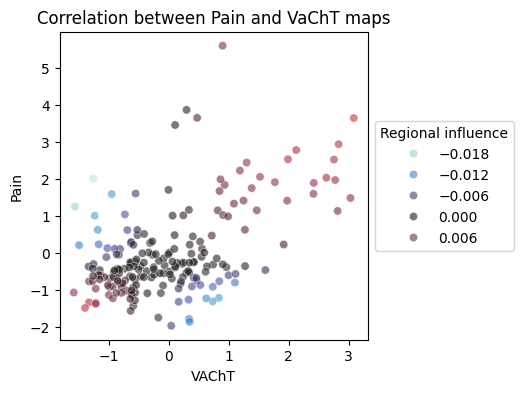

In [7]:
# visualize as scatter plot -> color regions by influence
infl = ri02[top_pet].squeeze()
fig, ax = plt.subplots(1, figsize=(4,4))
sn.scatterplot(x=x, y=y, alpha=0.6, 
               hue=infl, hue_norm=(-infl.abs().max(), infl.abs().max()), palette="icefire")
ax.set_box_aspect(1)
ax.set_title("Correlation between Pain and VaChT maps")
ax.set_xlabel("VAChT")
ax.legend(loc="center left", bbox_to_anchor=(1,0.5), title=f"Regional influence")

Regional influence is one value per parcel, so we can also project it on a brain. Below, we plot in compared to the two input maps.

WARNING | 15/07/26 09:48:19 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 15/07/26 09:48:19 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010


INFO | 15/07/26 09:48:19 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage


INFO | 15/07/26 09:48:19 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.


INFO | 15/07/26 09:48:19 | nispace.plotting: brainplot: threshold='auto' → 8.305642040795647e-06


INFO | 15/07/26 09:48:19 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.


INFO | 15/07/26 09:48:20 | nispace.core.parcellation: Parcellation 'Yan200': active space set to 'MNI152NLin2009cAsym'.


INFO | 15/07/26 09:48:20 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


(<Figure size 720x630 with 18 Axes>, [<Axes: >, <Axes: >, <Axes: >])

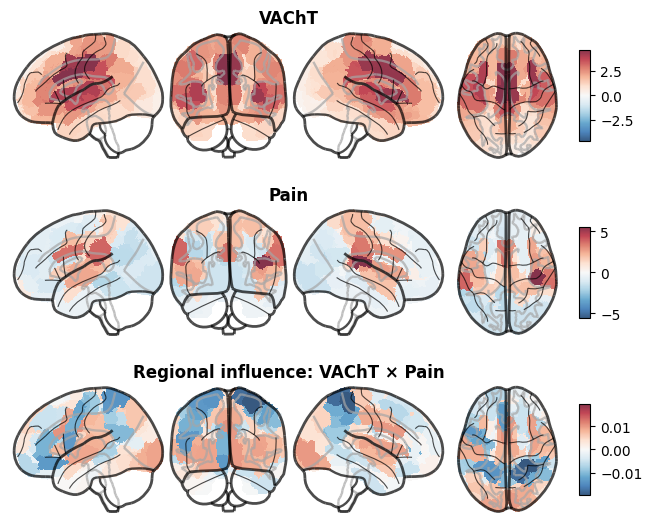

In [8]:
brainplot(
    [x - x.min(), y, infl], # rescale x because 0 is meaningless here
    title=["VAChT", "Pain", "Regional influence: VAChT × Pain"],
    parcellation="Yan200",
)

### Regional contribution

Regional influence asks *how much does removing this region change the correlation?* Regional contribution asks a different, simpler question: *how much does this region add to the correlation?*

$$\text{contribution}_i = z_{X,i} \cdot z_{Y,i}$$

where $z_{X,i}$ and $z_{Y,i}$ are the standardized values at region $i$, computed over the same shared NaN mask that the correlation itself uses. This is the **exact additive decomposition** of Pearson's $\rho$: the mean over all regions equals the observed correlation exactly. It requires no leave-one-out refitting and is O(n) in compute.

The key advantage over regional influence is the **quadrant** label, which breaks a symmetry that LOO cannot:
- `high_high` — both maps above their means here (co-elevation)
- `low_low` — both maps below their means here (co-depression)
- `discordant` — maps on opposite sides of their respective means

Regional influence assigns the same positive delta to a high-high and a low-low region (both reinforce a positive rho identically). Regional contribution's quadrant label distinguishes them, which is often the scientifically relevant distinction.

> **Note**: regional contribution is scoped to the 4 correlation methods (`pearson`, `spearman`, `partialpearson`, `partialspearman`). R²-based methods (`mlr`, `dominance`, `pls`, `pcr`) do not have an equivalent additive decomposition.

In [9]:
# Calculate and get contribution
nsp02.regional_contribution()
rc02 = nsp02.get_regional_contribution()
contrib = rc02[top_pet].squeeze()

# Verify the additive decomposition: mean(contribution) should equal rho
rho = nsp02.get_colocalizations().loc["Pain", top_pet]
print(f"rho (from colocalize, back-transformed from Z): {np.tanh(rho):.6f}")
print(f"mean(contribution) (decomposed):                {contrib.mean():.6f}")

# Top 5 contributing regions
print("\nTop 5 contributing regions:")
top5 = contrib.sort_values(ascending=False).head(5)
for parcel, val in top5.items():
    print(f"  {val:+.4f} {parcel}")

INFO | 15/07/26 09:48:30 | nispace.api: *** NiSpace.regional_contribution() - Estimating regional contribution. ***


Regional contribution (spearman, 4 proc): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 2019.40it/s]

INFO | 15/07/26 09:48:32 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 


rho (from colocalize, back-transformed from Z): 0.399273
mean(contribution) (decomposed):                0.399272

Top 5 contributing regions:
  +2.8806 hemi-L_div-SalVenAttnB_lab-FrMed
  +2.7642 hemi-R_div-SalVenAttnB_lab-FrMed
  +2.7358 hemi-R_div-VisualB_lab-Striate+2
  +2.5941 hemi-R_div-SalVenAttnB_lab-Ins
  +2.5386 hemi-L_div-VisualC_lab-ExStr


WARNING | 15/07/26 09:48:32 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 15/07/26 09:48:32 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010


INFO | 15/07/26 09:48:32 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage


INFO | 15/07/26 09:48:32 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.


INFO | 15/07/26 09:48:32 | nispace.plotting: brainplot: threshold='auto' → 8.305642040795647e-06


INFO | 15/07/26 09:48:32 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.


INFO | 15/07/26 09:48:32 | nispace.core.parcellation: Parcellation 'Yan200': active space set to 'MNI152NLin2009cAsym'.


INFO | 15/07/26 09:48:32 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


(<Figure size 720x420 with 12 Axes>, [<Axes: >, <Axes: >])

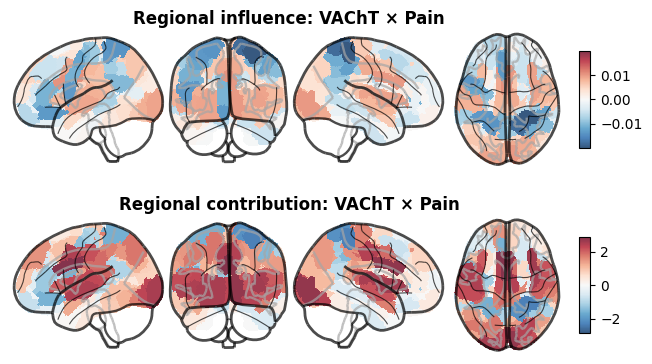

In [10]:
# plot compared to regional influence from above (should look quite similar)
brainplot(
    [infl, contrib],
    title=["Regional influence: VAChT × Pain", "Regional contribution: VAChT × Pain"],
    parcellation="Yan200",
)

## Example 2: XSEA (cell type enrichment)

For XSEA, `regional_influence()` picks up the `xsea=True` setting automatically from the last `colocalize()` call. The result dict is keyed by **cell type set labels** rather than individual gene labels.

In [11]:
# Regional influence for XSEA (auto picks up xsea=True from last colocalize)
nsp10.regional_influence()

ri10 = nsp10.get_regional_influence()
print(f"Type: {type(ri10)}")
print(f"Keys (cell types): {list(ri10.keys())}")

INFO | 15/07/26 09:48:40 | nispace.api: *** NiSpace.regional_influence() - Estimating regional influence. ***


Regional influence (spearman, analytic, 4 proc): 100%|███████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 2657.99it/s]

Type: <class 'dict'>
Keys (cell types): ['Ex1 CortProject (L2/3)', 'Ex2 Granule (L3/4)', 'Ex3 Granule (L4)', 'Ex4 SubcortProject (L4)', 'Ex5 SubcortProject (L4-6)', 'Ex6 SubcortProject (L5-6)', 'Ex7 Corticothalamic', 'Ex8 Corticothalamic (L6)', 'In1 VIP+RELN+NDNF+ (L1/2)', 'In2 VIP+RELN-NDNF- (L6)', 'In3 VIP+RELN+NDNF- (L6)', 'In4 VIP-RELN+NDNF+ (L1-3)', 'In5 CCK+NOS1+CALB2+ (L2/3)', 'In6 PVALB+CRHBP+ (L4/5)', 'In7 SST+CALB1+NPY+ (L5/6)', 'In8 SST+NOS1+ (L6)', 'Astrocyte', 'Endothelial', 'Developing-quiescent', 'Developing-replicating', 'Microglia', 'Other Neurons', 'OPC', 'Oligodendrocyte']


INFO | 15/07/26 09:48:40 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 


Top cell type: Microglia
WARNING | 15/07/26 09:48:40 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 15/07/26 09:48:40 | nispace.core.parcellation: Building combined Parcellation 'Yan100+TianS1' from library.


INFO | 15/07/26 09:48:40 | nispace.core.parcellation:   Common MNI space(s) for combined: ['MNI152NLin2009cAsym', 'MNI152NLin6Asym'].


INFO | 15/07/26 09:48:40 | nispace.core.parcellation:   Merging 'Yan100' and 'TianS1' for space 'MNI152NLin2009cAsym'.


...

INFO | 15/07/26 09:48:40 | nispace.plotting: brainplot: threshold='auto' → 3.452582632235135e-06


INFO | 15/07/26 09:48:40 | nispace.core.parcellation: Parcellation 'Yan100+TianS1': active space set to 'MNI152NLin2009cAsym'.


INFO | 15/07/26 09:48:40 | nispace.core.parcellation: Combined parcellation: cx-LH parcels = 50, cx-RH parcels = 50.


INFO | 15/07/26 09:48:40 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


(<Figure size 720x180 with 6 Axes>, [<Axes: >])

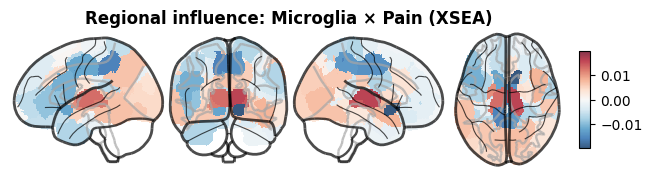

In [12]:
# Top cell type by |mean rho|
top_ct = nsp10.get_colocalizations().loc["Pain"].abs().idxmax()
print(f"Top cell type: {top_ct}")

brainplot(
    ri10[top_ct],
    parcellation="Yan100+TianS1",
    title=f"Regional influence: {top_ct} × Pain (XSEA)",
)

## Multi-Y pooling

Both examples above have a single Y map (the pain map), so the result is a (1 × n_parcels) DataFrame per receptor/set.

For multi-subject designs (n_Y > 1), each row of the result DataFrame corresponds to one subject's influence profile. `get_regional_influence(pooled="mean")` collapses across subjects, giving a single (1 × n_parcels) DataFrame per key:

```python
# Example: multi-subject — n_Y = number of subjects
nsp_multi.regional_influence()
ri_pooled = nsp_multi.get_regional_influence(pooled="mean")  # averages across subjects
```

Use `pooled="median"` for robustness to outlier subjects.

## Summary

- `nsp.regional_influence()` computes influence per region: how much does removing a region change the colocalization? Result is `|stat_full| − |stat_loo|` by default (unsigned); `signed=True` restores the raw directional delta.
- `get_regional_influence()` returns a dict (per-pair methods like spearman) or a DataFrame (joint-model methods like mlr).
- `engine="auto"` picks the analytic closed-form for `pearson`/`spearman`/`partialpearson`/`partialspearman`/`mlr`, and bruteforce for all others.
- `lasso`, `ridge`, `elasticnet` are not supported (their closures fix the data size at fit time).
- XSEA is supported: influence reflects how each region shapes the set-level mean colocalization.
- For multi-subject data, use `get_regional_influence(pooled="mean")` to aggregate across subjects.
- `nsp.regional_contribution()` provides a complementary O(n) decomposition: `contribution_i = zx_i * zy_i`, whose mean equals rho exactly. Use `get_regional_contribution(quadrant=True)` to retrieve the `high_high`/`low_low`/`discordant` label per region — the distinction that regional influence alone cannot make.